# Projeto: Monitor de Sentimento do COPOM via NLP
Este notebook automatiza a coleta e análise das atas do Comitê de Política Monetária (COPOM) do Banco Central do Brasil. O objetivo é transformar textos brutos em indicadores quantitativos de incerteza e estabilidade.

### 🛠 Instalação de Dependências
Instalamos as bibliotecas necessárias para:
* **Extração de Dados**: `pdfplumber` e `requests`.
* **Processamento de Dados**: `pandas` e `jinja2` (estilização).
* **NLP & Estatística**: `nltk`, `scikit-learn` e `wordcloud`.
* **Visualização**: `matplotlib`.

In [1]:
%pip install requests pandas pdfplumber nltk wordcloud matplotlib scikit-learn jinja2

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Extração Automatizada (Scraping)
Nesta etapa, utilizamos a API oficial do Banco Central para localizar os PDFs das atas mais recentes. 
* O script baixa o arquivo em memória.
* Extrai o texto de todas as páginas.
* Consolida tudo em um **DataFrame do Pandas** (nosso Corpus de pesquisa).

In [2]:
import requests
import pandas as pd
import pdfplumber
import io
import warnings
import time

warnings.filterwarnings('ignore')

class CopomBulkScraper:
    def __init__(self, qtd_atas=100):
        self.api_url = f"https://www.bcb.gov.br/api/servico/sitebcb/atascopom/ultimas?quantidade={qtd_atas}&filtro="
        self.headers = {
            "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36",
            "Referer": "https://www.bcb.gov.br/publicacoes/atascopom"
        }

    def obter_dataframe_completo(self):
        print(f"⏳ Acessando API para buscar as últimas atas...")
        response = requests.get(self.api_url, headers=self.headers, verify=False)
        if response.status_code != 200:
            return None

        dados = response.json().get('conteudo', [])
        df = pd.DataFrame(dados)
        df['link_pdf'] = "https://www.bcb.gov.br" + df['Url']
        df['texto_integral'] = ""

        print(f"✅ Encontradas {len(df)} atas. Iniciando extração de texto...")
        for index, row in df.iterrows():
            print(f"📦 Processando: {row['Titulo']}")
            df.at[index, 'texto_integral'] = self._baixar_e_extrair(row['link_pdf'])
            time.sleep(1)
        return df[['Titulo', 'DataReferencia', 'texto_integral', 'link_pdf']]

    def _baixar_e_extrair(self, url):
        try:
            res = requests.get(url, headers=self.headers, verify=False)
            with pdfplumber.open(io.BytesIO(res.content)) as pdf:
                return "\n".join([pagina.extract_text() for pagina in pdf.pages if pagina.extract_text()])
        except:
            return "ERRO"

scraper = CopomBulkScraper(qtd_atas=100)
df_copom = scraper.obter_dataframe_completo()
display(df_copom.head())

⏳ Acessando API para buscar as últimas atas...
✅ Encontradas 100 atas. Iniciando extração de texto...
📦 Processando: 277ª Reunião - 17-18 março, 2026
📦 Processando: 276ª Reunião - 27-28 janeiro, 2026
📦 Processando: 275ª Reunião - 9-10 dezembro, 2025
📦 Processando: 274ª Reunião - 4-5 novembro, 2025
📦 Processando: 273ª Reunião - 16-17 setembro, 2025
📦 Processando: 272ª Reunião - 29-30 julho, 2025
📦 Processando: 271ª Reunião - 17-18 junho, 2025
📦 Processando: 270ª Reunião - 6-7 maio, 2025
📦 Processando: 269ª Reunião - 18-19 março, 2025
📦 Processando: 268ª Reunião - 28-29 janeiro, 2025
📦 Processando: 267ª Reunião - 10-11 dezembro, 2024
📦 Processando: 266ª Reunião - 5-6 novembro, 2024
📦 Processando: 265ª Reunião - 17-18 setembro, 2024
📦 Processando: 264ª Reunião - 30-31 julho, 2024
📦 Processando: 263ª Reunião - 18-19 junho, 2024
📦 Processando: 262ª Reunião - 7-8 maio, 2024
📦 Processando: 261ª Reunião - 19-20 março, 2024
📦 Processando: 260ª Reunião - 30-31 janeiro, 2024
📦 Processando: 259ª R

,Titulo,DataReferencia,texto_integral,link_pdf
0,"277ª Reunião - 17-18 março, 2026",2026-03-18T03:00:00Z,277ª\nAta da Reunião do\nComitê de Política Mo...,https://www.bcb.gov.br/content/copom/atascopom...
1,"276ª Reunião - 27-28 janeiro, 2026",2026-01-28T03:00:00Z,276ª\nAta da Reunião do\nComitê de Política Mo...,https://www.bcb.gov.br/content/copom/atascopom...
2,"275ª Reunião - 9-10 dezembro, 2025",2025-12-10T03:00:00Z,275ª\nAta da Reunião do\nComitê de Política Mo...,https://www.bcb.gov.br/content/copom/atascopom...
3,"274ª Reunião - 4-5 novembro, 2025",2025-11-05T03:00:00Z,274ª\nAta da Reunião do\nComitê de Política Mo...,https://www.bcb.gov.br/content/copom/atascopom...
4,"273ª Reunião - 16-17 setembro, 2025",2025-09-17T03:00:00Z,273ª\nAta da Reunião do\nComitê de Política Mo...,https://www.bcb.gov.br/content/copom/atascopom...


In [8]:
df_copom.head(70)

,Titulo,DataReferencia,texto_integral,link_pdf
0,"277ª Reunião - 17-18 março, 2026",2026-03-18T03:00:00Z,277ª\nAta da Reunião do\nComitê de Política Mo...,https://www.bcb.gov.br/content/copom/atascopom...
1,"276ª Reunião - 27-28 janeiro, 2026",2026-01-28T03:00:00Z,276ª\nAta da Reunião do\nComitê de Política Mo...,https://www.bcb.gov.br/content/copom/atascopom...
2,"275ª Reunião - 9-10 dezembro, 2025",2025-12-10T03:00:00Z,275ª\nAta da Reunião do\nComitê de Política Mo...,https://www.bcb.gov.br/content/copom/atascopom...
3,"274ª Reunião - 4-5 novembro, 2025",2025-11-05T03:00:00Z,274ª\nAta da Reunião do\nComitê de Política Mo...,https://www.bcb.gov.br/content/copom/atascopom...
4,"273ª Reunião - 16-17 setembro, 2025",2025-09-17T03:00:00Z,273ª\nAta da Reunião do\nComitê de Política Mo...,https://www.bcb.gov.br/content/copom/atascopom...
...,...,...,...,...
65,212ª Reunião,2018-02-07T02:00:00Z,Ata da 212ª Reunião do\nComitê de Política Mon...,https://www.bcb.gov.br/content/copom/atascopom...
66,211ª Reunião,2017-12-06T02:00:00Z,Notas da 211ª Reunião do\nComitê de Política M...,https://www.bcb.gov.br/content/copom/atascopom...
67,210ª Reunião,2017-10-25T02:00:00Z,Notas da 210ª Reunião do\nComitê de Política M...,https://www.bcb.gov.br/content/copom/atascopom...
68,209ª Reunião,2017-09-06T03:00:00Z,Notas da 209ª Reunião do\nComitê de Política M...,https://www.bcb.gov.br/content/copom/atascopom...


📡 Acessando API do Banco Central...
✅ 100 entradas mapeadas. Iniciando extração de texto...
📦 [1/100] Processando: 277ª Reunião - 17-18 março, 2026
📦 [2/100] Processando: 276ª Reunião - 27-28 janeiro, 2026
📦 [3/100] Processando: 275ª Reunião - 9-10 dezembro, 2025
📦 [4/100] Processando: 274ª Reunião - 4-5 novembro, 2025
📦 [5/100] Processando: 273ª Reunião - 16-17 setembro, 2025
📦 [6/100] Processando: 272ª Reunião - 29-30 julho, 2025
📦 [7/100] Processando: 271ª Reunião - 17-18 junho, 2025
📦 [8/100] Processando: 270ª Reunião - 6-7 maio, 2025
📦 [9/100] Processando: 269ª Reunião - 18-19 março, 2025
📦 [10/100] Processando: 268ª Reunião - 28-29 janeiro, 2025
📦 [11/100] Processando: 267ª Reunião - 10-11 dezembro, 2024
📦 [12/100] Processando: 266ª Reunião - 5-6 novembro, 2024
📦 [13/100] Processando: 265ª Reunião - 17-18 setembro, 2024
📦 [14/100] Processando: 264ª Reunião - 30-31 julho, 2024
📦 [15/100] Processando: 263ª Reunião - 18-19 junho, 2024
📦 [16/100] Processando: 262ª Reunião - 7-8 maio,

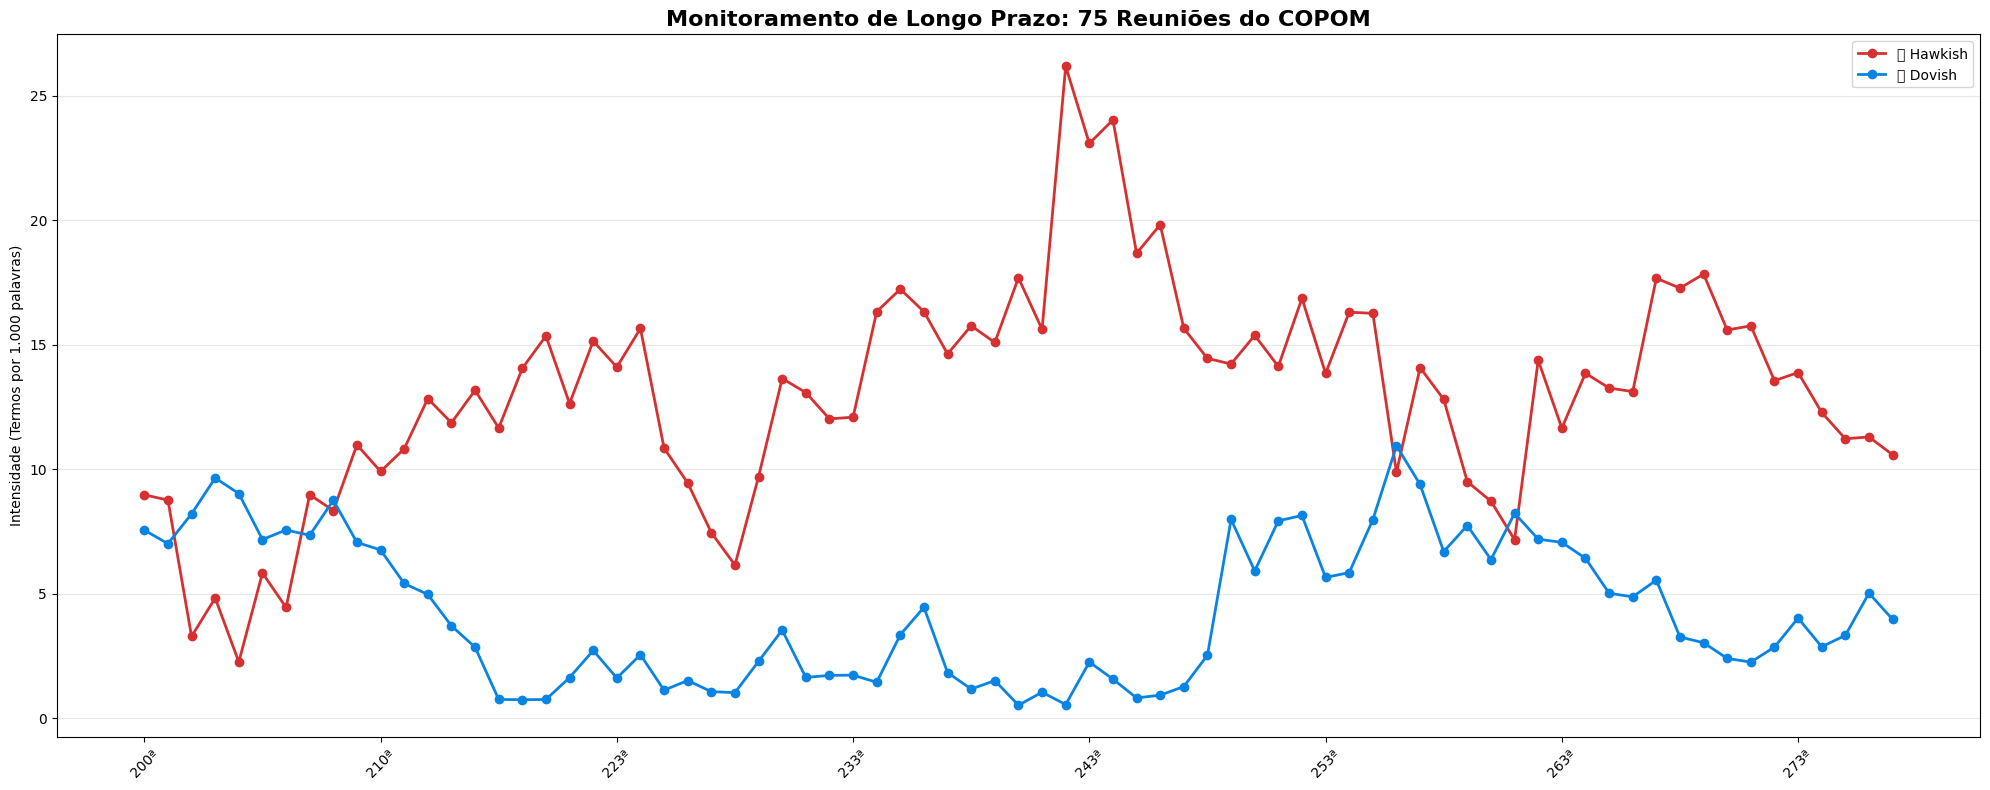

In [9]:
import requests
import pandas as pd
import pdfplumber
import io
import re
import time
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

# --- 1. CLASSE SCRAPER PRO (RESOLVE ERRO DE NAN/FLOAT) ---
class CopomBulkScraperPro:
    def __init__(self, qtd_atas=100):
        self.api_url = f"https://www.bcb.gov.br/api/servico/sitebcb/atascopom/ultimas?quantidade={qtd_atas}&filtro="
        self.headers = {
            "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36",
            "Referer": "https://www.bcb.gov.br/publicacoes/atascopom"
        }

    def obter_dados(self):
        print(f"📡 Acessando API do Banco Central...")
        res = requests.get(self.api_url, headers=self.headers, verify=False)
        if res.status_code != 200: return None
        
        df = pd.DataFrame(res.json().get('conteudo', []))

        # CORREÇÃO: Trata NaNs e converte para link absoluto
        def limpar_link(row):
            url = row.get('Url')
            if pd.isna(url) or not url: # Se Url falhar, tenta UrlArquivo
                url = row.get('UrlArquivo')
            
            if pd.isna(url) or not url: return ""
            
            url_str = str(url) # Força string para evitar AttributeError: float
            return "https://www.bcb.gov.br" + url_str if not url_str.startswith('http') else url_str

        df['link_pdf'] = df.apply(limpar_link, axis=1)
        df['texto_integral'] = ""

        print(f"✅ {len(df)} entradas mapeadas. Iniciando extração de texto...")
        for idx, row in df.iterrows():
            if not row['link_pdf'] or ".pdf" not in row['link_pdf'].lower():
                df.at[idx, 'texto_integral'] = "LINK_NAO_DISPONIVEL"
                continue
            
            print(f"📦 [{idx+1}/{len(df)}] Processando: {row['Titulo']}")
            df.at[idx, 'texto_integral'] = self._extrair_pdf(row['link_pdf'])
            time.sleep(0.5)
            
        return df

    def _extrair_pdf(self, url):
        try:
            res = requests.get(url, headers=self.headers, verify=False, timeout=15)
            with pdfplumber.open(io.BytesIO(res.content)) as pdf:
                return "\n".join([p.extract_text() for p in pdf.pages if p.extract_text()])
        except:
            return "ERRO_NA_LEITURA"

# --- 2. MOTOR DE ANÁLISE DE SENTIMENTO (NÍVEL 2) ---
lexico = {
    'hawkish': ['eleva', 'aperto', 'inflacionário', 'desancora', 'persiste', 'risco', 'pressão', 'vigilân', 'fiscal'],
    'dovish': ['reduz', 'corte', 'flexibiliza', 'desinflação', 'hiato', 'arrefecimento', 'suave', 'queda']
}

def analisar_tom(texto):
    if not texto or len(texto) < 100: return 0, 0
    t = texto.lower()
    total = len(t.split())
    h = len(re.findall(r'\b(' + '|'.join(lexico['hawkish']) + r')\w*\b', t))
    d = len(re.findall(r'\b(' + '|'.join(lexico['dovish']) + r')\w*\b', t))
    return (h/total)*1000, (d/total)*1000

# --- 3. EXECUÇÃO DO PROCESSO ---
scraper = CopomBulkScraperPro(qtd_atas=100)
df_copom = scraper.obter_dados()

# Limpeza e Cálculo
df_analise = df_copom[df_copom['texto_integral'].str.len() > 100].copy()
scores = df_analise['texto_integral'].apply(analisar_tom)
df_analise[['h_score', 'd_score']] = pd.DataFrame(scores.tolist(), index=df_analise.index)

# Inverte para o gráfico ficar cronológico
df_plot = df_analise.iloc[::-1].copy()
df_plot['Label'] = df_plot['Titulo'].apply(lambda x: str(x).split(' ')[0])

# --- 4. GRÁFICO OTIMIZADO PARA 100 ATAS ---
plt.figure(figsize=(20, 8))
plt.plot(df_plot['Label'], df_plot['h_score'], color='#d63031', marker='o', label='🦅 Hawkish', linewidth=2)
plt.plot(df_plot['Label'], df_plot['d_score'], color='#0984e3', marker='o', label='🕊️ Dovish', linewidth=2)

# Ajuste do Eixo X: Mostra 1 label a cada 10 para não embolar
plt.xticks(df_plot['Label'][::10], rotation=45)
plt.title(f'Monitoramento de Longo Prazo: {len(df_plot)} Reuniões do COPOM', fontsize=16, fontweight='bold')
plt.ylabel('Intensidade (Termos por 1.000 palavras)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
df_copom.head(78)

,DataReferencia,ImagemCapa,Titulo,Url,LinkPagina,EsconderDataReferencia,link_final,texto_integral
0,2026-03-18T03:00:00Z,/content/publicacoes/PublishingImages/Capas/at...,"277ª Reunião - 17-18 março, 2026",/content/copom/atascopom/Copom277-not202603182...,/publicacoes/atascopom/18032026,True,https://www.bcb.gov.br/content/copom/atascopom...,277ª\nAta da Reunião do\nComitê de Política Mo...
1,2026-01-28T03:00:00Z,/content/publicacoes/PublishingImages/Capas/at...,"276ª Reunião - 27-28 janeiro, 2026",/content/copom/atascopom/Copom276-not202601282...,/publicacoes/atascopom/28012026,True,https://www.bcb.gov.br/content/copom/atascopom...,276ª\nAta da Reunião do\nComitê de Política Mo...
2,2025-12-10T03:00:00Z,/content/publicacoes/PublishingImages/Capas/at...,"275ª Reunião - 9-10 dezembro, 2025",/content/copom/atascopom/Copom275-not202512102...,/publicacoes/atascopom/10122025,True,https://www.bcb.gov.br/content/copom/atascopom...,275ª\nAta da Reunião do\nComitê de Política Mo...
3,2025-11-05T03:00:00Z,/content/publicacoes/PublishingImages/Capas/at...,"274ª Reunião - 4-5 novembro, 2025",/content/copom/atascopom/Copom274-not202511052...,/publicacoes/atascopom/05112025,True,https://www.bcb.gov.br/content/copom/atascopom...,274ª\nAta da Reunião do\nComitê de Política Mo...
4,2025-09-17T03:00:00Z,/content/publicacoes/PublishingImages/Capas/at...,"273ª Reunião - 16-17 setembro, 2025",/content/copom/atascopom/Copom273-not202509172...,/publicacoes/atascopom/17092025,True,https://www.bcb.gov.br/content/copom/atascopom...,273ª\nAta da Reunião do\nComitê de Política Mo...
...,...,...,...,...,...,...,...,...
73,2017-01-11T02:00:00Z,/content/publicacoes/PublishingImages/Capas/at...,204ª Reunião,/content/copom/atascopom/COPOM204-not201701112...,/publicacoes/atascopom/11012017,None,https://www.bcb.gov.br/content/copom/atascopom...,Notas da 204ª Reunião do\nComitê de Política M...
74,2016-11-30T02:00:00Z,/content/publicacoes/PublishingImages/Capas/at...,203ª Reunião,/content/copom/atascopom/COPOM203-not201611302...,/publicacoes/atascopom/30112016,None,https://www.bcb.gov.br/content/copom/atascopom...,Notas da 203ª Reunião do\nComitê de Política M...
75,2016-10-19T02:00:00Z,/content/publicacoes/PublishingImages/Capas/at...,202ª Reunião,/content/copom/atascopom/COPOM202-not201610192...,/publicacoes/atascopom/19102016,None,https://www.bcb.gov.br/content/copom/atascopom...,Notas da 202ª Reunião do\nComitê de Política M...
76,2016-08-31T03:00:00Z,/content/publicacoes/PublishingImages/Capas/at...,201ª Reunião,/content/copom/atascopom/COPOM201-not201608312...,/publicacoes/atascopom/31082016,None,https://www.bcb.gov.br/content/copom/atascopom...,Notas da 201ª Reunião do\nComitê de Política M...


## 2. Nível 1: Análise Visual (Nuvem de Palavras)
A primeira camada de análise foca na **frequência de termos**. 
* **Stopwords**: Removemos palavras irrelevantes (artigos, preposições) e termos técnicos de rodapé.
* **Insight**: O tamanho da palavra na nuvem indica sua dominância no discurso daquela reunião específica.

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
import re

nltk.download('stopwords')
stop_words = set(stopwords.words('portuguese'))
stop_words.update(['reunião', 'copom', 'ata', 'bcb', 'membros', 'sobre', 'ainda', 'pode', 'janeiro', 'fevereiro', 'março', 'abril', 'maio', 'junho', 'julho', 'agosto', 'setembro', 'outubro', 'novembro', 'dezembro'])

def gerar_nuvens(df):
    for index, row in df.iterrows():
        texto_limpo = re.sub(r'[^\w\s]', '', row['texto_integral'].lower())
        texto_limpo = re.sub(r'\d+', '', texto_limpo)
        wc = WordCloud(width=800, height=400, background_color='white', stopwords=stop_words, colormap='viridis').generate(texto_limpo)
        plt.figure(figsize=(10, 5))
        plt.imshow(wc, interpolation='bilinear')
        plt.title(f"Temas: {row['Titulo']}")
        plt.axis('off')
        plt.show()

gerar_nuvens(df_copom)

## 3. Nível 2: Monitor de Sentimento e Sinalização de Mercado
Nesta etapa, evoluímos a análise para um Monitor de Sentimento Quantitativo. Em vez de apenas identificar palavras soltas, passamos a medir o "tom" (vibe) do Banco Central para entender se ele está sinalizando uma alta ou queda nos juros.

🦅 O Duelo de Narrativas: Hawkish vs Dovish

In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. DICIONÁRIO EXPANDIDO DE INVESTIMENTOS ---
lexico_investimentos = {
    'hawkish': [
        'eleva', 'aperto', 'inflacionário', 'desancora', 'persiste', 'risco', 
        'pressão', 'vigilân', 'resiliência', 'acelera', 'altista', 'piora', 
        'deterioração', 'firmeza', 'prudência', 'acima', 'restritiv', 
        'contracionista', 'aquecid', 'remanescente', 'dinâmica', 'fiscal', 
        'déficit', 'dívida', 'sobreaquecimento', 'excesso', 'desvio',
        'perseverança', 'incisiva', 'tenacidade', 'magnitude', 'convergência'
    ],
    'dovish': [
        'reduz', 'corte', 'flexibiliza', 'desinflação', 'hiato', 'arrefecimento', 
        'moderado', 'estímulo', 'queda', 'estabilidade', 'suave', 'desacelera', 
        'benigno', 'contração', 'ociosidade', 'abaixo', 'confortável', 
        'expansionista', 'branda', 'leve', 'recuo', 'desaquecimento', 
        'acomodaticia', 'gradualismo', 'parcimônia', 'ancorada', 'melhora',
        'trajetória', 'flexível', 'interrupção', 'pausa'
    ]
}

def calcular_intensidade_investimento(texto):
    if not texto or texto == "ERRO": return 0, 0
    texto_limpo = texto.lower()
    total_palavras = len(texto_limpo.split())
    
    h_count = len(re.findall(r'\b(' + '|'.join(lexico_investimentos['hawkish']) + r')\w*\b', texto_limpo))
    d_count = len(re.findall(r'\b(' + '|'.join(lexico_investimentos['dovish']) + r')\w*\b', texto_limpo))
    
    h_score = (h_count / total_palavras) * 1000
    d_score = (d_count / total_palavras) * 1000
    
    return h_score, d_score

# --- 2. PROCESSAMENTO ---
resumo = df_copom['texto_integral'].apply(calcular_intensidade_investimento)
df_copom[['h_score', 'd_score']] = pd.DataFrame(resumo.tolist(), index=df_copom.index)

# Inverter para ordem cronológica
df_plot = df_copom.iloc[::-1].copy()
df_plot['Label_Curto'] = df_plot['Titulo'].apply(lambda x: str(x).split(' ')[0])

# --- 3. GRÁFICO OTIMIZADO PARA 30+ REUNIÕES ---
plt.figure(figsize=(18, 8)) # Largura maior para séries longas

# Linhas de Sentimento
plt.plot(df_plot['Label_Curto'], df_plot['h_score'], color='#d63031', marker='o', 
         linewidth=3, label='🦅 Força Hawkish (Preocupação/Juro Alto)', markersize=7)

plt.plot(df_plot['Label_Curto'], df_plot['d_score'], color='#0984e3', marker='o', 
         linewidth=3, label='🕊️ Força Dovish (Suavidade/Juro Baixo)', markersize=7)

# --- AJUSTE DO EIXO X (O SEGREDO PARA NÃO FICAR ZUADO) ---
# Mostra apenas 1 label a cada 5 reuniões para não embolar
plt.xticks(df_plot['Label_Curto'][::5], fontsize=11) 

# Estética
plt.title('Duelo de Discurso: Histórico de Longo Prazo do COPOM', fontsize=18, fontweight='bold', pad=20)
plt.ylabel('Intensidade por 1.000 palavras', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.legend(fontsize=12, loc='upper left', frameon=True)

# Destaque para a situação atual (sempre no último ponto)
plt.annotate('Situação Atual', 
             xy=(len(df_plot)-1, df_plot['h_score'].iloc[-1]), 
             xytext=(len(df_plot)-4, df_plot['h_score'].iloc[-1]+5),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1),
             fontsize=12, fontweight='bold', bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.8))

plt.tight_layout()
plt.show()

print(f"📊 Análise de {len(df_plot)} reuniões finalizada com sucesso.")

In [ ]:
import re
import pandas as pd
import requests
import matplotlib.pyplot as plt

# --- 1. DICIONÁRIO DE INVESTIMENTOS (LÉXICO PRO) ---
lexico_investimentos = {
    'hawkish': [
        'eleva', 'aperto', 'inflacionário', 'desancora', 'persiste', 'risco', 
        'pressão', 'vigilân', 'resiliência', 'acelera', 'altista', 'piora', 
        'deterioração', 'firmeza', 'prudência', 'acima', 'restritiv', 
        'contracionista', 'aquecid', 'remanescente', 'dinâmica', 'fiscal', 
        'déficit', 'dívida', 'sobreaquecimento', 'excesso', 'desvio',
        'perseverança', 'incisiva', 'tenacidade', 'magnitude', 'convergência'
    ],
    'dovish': [
        'reduz', 'corte', 'flexibiliza', 'desinflação', 'hiato', 'arrefecimento', 
        'moderado', 'estímulo', 'queda', 'estabilidade', 'suave', 'desacelera', 
        'benigno', 'contração', 'ociosidade', 'abaixo', 'confortável', 
        'expansionista', 'branda', 'leve', 'recuo', 'desaquecimento', 
        'acomodaticia', 'gradualismo', 'parcimônia', 'ancorada', 'melhora',
        'trajetória', 'flexível', 'interrupção', 'pausa'
    ]
}

def calcular_intensidade(texto):
    if not texto or texto == "ERRO": return 0, 0
    t_limpo = texto.lower()
    total = len(t_limpo.split())
    h = len(re.findall(r'\b(' + '|'.join(lexico_investimentos['hawkish']) + r')\w*\b', t_limpo))
    d = len(re.findall(r'\b(' + '|'.join(lexico_investimentos['dovish']) + r')\w*\b', t_limpo))
    return (h/total)*1000, (d/total)*1000

# --- 2. BUSCAR SELIC (DATA INICIAL AMPLIADA PARA 40 ATAS) ---
print("📡 Buscando histórico da Selic no BCB...")
# Buscamos desde 2020 para garantir cobertura das 40 reuniões
url_selic = "https://api.bcb.gov.br/dados/serie/bcdata.sgs.432/dados?formato=json&dataInicial=01/01/2020"

try:
    res = requests.get(url_selic, timeout=60)
    df_selic = pd.DataFrame(res.json())
    df_selic['data'] = pd.to_datetime(df_selic['data'], dayfirst=True)
    df_selic['valor'] = pd.to_numeric(df_selic['valor'])

    # --- 3. PROCESSAMENTO E ALINHAMENTO ---
    df_analise = df_copom.copy()
    scores = df_analise['texto_integral'].apply(calcular_intensidade)
    df_analise[['h_score', 'd_score']] = pd.DataFrame(scores.tolist(), index=df_analise.index)
    df_analise['data_dt'] = pd.to_datetime(df_analise['DataReferencia'].str[:10])
    
    # Merge Asof para sincronizar Ata com a Selic da época
    df_final = pd.merge_asof(df_analise.sort_values('data_dt'), 
                             df_selic.sort_values('data'), 
                             left_on='data_dt', right_on='data', direction='backward')

    # --- 4. GRÁFICO PARA SÉRIES LONGAS (FIX EIXO X) ---
    fig, ax1 = plt.subplots(figsize=(20, 8)) # Aumentado para 40 pontos
    
    df_final['Label_Curto'] = df_final['Titulo'].apply(lambda x: str(x).split(' ')[0])

    # Eixo 1: Sentimento (Hawkish e Dovish)
    ax1.plot(df_final['Label_Curto'], df_final['h_score'], color='#d63031', marker='o', 
             linewidth=3, label='🦅 Força Hawkish (Foco Inflação)', markersize=7)
    ax1.plot(df_final['Label_Curto'], df_final['d_score'], color='#0984e3', marker='o', 
             linewidth=3, label='🕊️ Força Dovish (Foco Crescimento)', markersize=7)
    
    ax1.set_ylabel('Intensidade (por 1.000 palavras)', fontsize=12, fontweight='bold')
    
    # Ajuste do Eixo X: Mostra 1 label a cada 5 para não embolar
    plt.xticks(df_final['Label_Curto'][::5], fontsize=11) 

    # Eixo 2: Selic (Gráfico em Escada)
    ax2 = ax1.twinx()
    ax2.step(df_final['Label_Curto'], df_final['valor'], color='black', 
             linewidth=5, alpha=0.5, where='post', label='💰 Taxa Selic Meta (%)')
    ax2.set_ylabel('Taxa Selic Meta (% a.a.)', fontsize=12, fontweight='bold')

    plt.title(f'Monitoramento de Longo Prazo: {len(df_final)} reuniões do COPOM', fontsize=18, fontweight='bold', pad=25)
    ax1.legend(loc='upper left'); ax2.legend(loc='upper right')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"❌ Erro: {e}")

## 4. Nível 3: Contexto e Bigramas (N-Grams)
Palavras soltas podem enganar. Para entender o contexto real, analisamos **duplas de palavras (Bigramas)**.
* **Foco**: O robô identifica o que acompanha as palavras-chave (Ex: "Risco *Fiscal*" vs "Risco *Externo*").
* **Aplicação**: Isso revela quais são os temas específicos que estão gerando os picos de incerteza detectados no nível anterior.

In [ ]:
from nltk.util import ngrams
from collections import Counter

def caçador_de_riscos(df):
    todas_as_duplas = []
    for texto in df['texto_integral']:
        palavras = [p for p in re.sub(r'[^\w\s]', '', texto.lower()).split() if p not in stop_words]
        todas_as_duplas.extend(list(ngrams(palavras, 2)))
    
    riscos = [bg for bg in todas_as_duplas if bg[0] in ['risco', 'incerteza', 'cenário']]
    return Counter(riscos).most_common(10)

print("🔍 Riscos e Cenários Reais Detectados:")
for r, freq in caçador_de_riscos(df_copom):
    print(f"{r[0]} {r[1]}: {freq} vezes")

In [ ]:
from nltk.util import ngrams
from collections import Counter
import pandas as pd

def radar_de_contexto(texto, top_n=10):
    if not texto or texto == "ERRO": return []
    
    # 1. Limpeza e Tokenização (reutilizando sua lógica)
    palavras = [p for p in re.sub(r'[^\w\s]', '', texto.lower()).split() if p not in stop_words]
    
    # 2. Gerar Bigramas
    duplas = list(ngrams(palavras, 2))
    
    # 3. Filtrar termos que realmente interessam para um analista
    # Queremos saber o que vem DEPOIS de palavras de alerta
    termos_chave = ['risco', 'incerteza', 'cenário', 'inflação', 'expectativas', 'balanço']
    contextos = [bg for bg in duplas if bg[0] in termos_chave]
    
    return Counter(contextos).most_common(top_n)

# --- APLICAÇÃO PRÁTICA ---
# Vamos pegar a ATA MAIS RECENTE (Posição 0 no seu df_copom)
ultima_ata = df_copom.iloc[0]
contextos_atuais = radar_de_contexto(ultima_ata['texto_integral'])

print(f"🎯 FOCO DE CONTEXTO DA {ultima_ata['Titulo']}:")
print("-" * 50)
for (p1, p2), freq in contextos_atuais:
    print(f"👉 {p1.upper()} {p2.upper()}: citado {freq} vezes")

## 5. Nível 4: Estabilidade de Discurso (Similaridade)
O teste final de rigor. Utilizamos **Similaridade de Cosseno** e vetores **TF-IDF** para comparar matematicamente a ata atual com a anterior.
* **Estabilidade (> 90%)**: O discurso é mantido, sinalizando previsibilidade.
* **Ruptura (< 85%)**: O Banco Central alterou significativamente a redação, o que geralmente precede mudanças na trajetória da taxa Selic.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt

# 1. Vetorização e Similaridade
vectorizer = TfidfVectorizer(stop_words=list(stop_words))
tfidf_matrix = vectorizer.fit_transform(df_copom['texto_integral'])

# Invertemos para processar da mais antiga para a mais nova
textos_inv = df_copom['texto_integral'].iloc[::-1].values
titulos_inv = df_copom['Titulo'].iloc[::-1].values
similaridades = []

for i in range(len(textos_inv) - 1):
    # Compara a ata (i+1) com a anterior (i)
    sim = cosine_similarity(tfidf_matrix[len(textos_inv)-1-i], 
                            tfidf_matrix[len(textos_inv)-2-i])[0][0]
    similaridades.append(sim)

# 2. Plotagem Profissional
plt.figure(figsize=(18, 7)) # Largura maior para não embolar
ax = plt.gca()

# Criamos labels curtos (ex: "268ª")
labels_curtos = [t.split('-')[0].strip() for t in titulos_inv[1:]]

# Plotagem com estilo de "Dashboard Financeiro"
plt.plot(labels_curtos, similaridades, marker='s', color='#6A0DAD', 
         linestyle='--', linewidth=2, markersize=8, label='Similaridade entre Atas')

# --- AJUSTE DO EIXO X (RESOLVENDO O PROBLEMA VISUAL) ---
# Mostra apenas 1 label a cada 5 reuniões para manter a legibilidade
plt.xticks(labels_curtos[::5], fontsize=11) 

# --- MELHORIAS NO EIXO Y ---
plt.ylim(0.65, 1.0) # Ajustado para mostrar quedas maiores se houver
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# --- LINHAS DE REFERÊNCIA (CRUCIAL PARA ANÁLISE) ---
plt.axhline(y=0.90, color='green', linestyle=':', alpha=0.5, label='Estabilidade (>90%)')
plt.axhline(y=0.85, color='red', linestyle=':', alpha=0.5, label='Zona de Ruptura (<85%)')

# --- ESTÉTICA ---
plt.title('Estabilidade do Discurso: O Banco Central está mudando o roteiro?', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Nível de Similaridade (%)', fontsize=12)
plt.grid(True, axis='y', alpha=0.2, linestyle=':')
plt.legend(loc='lower left', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
import re
import pandas as pd
from nltk.util import ngrams
from IPython.display import display

# 1. DEFINIÇÃO DA FUNÇÃO (O que estava faltando na sua memória)
def extrair_conjunto_bigramas(texto):
    """Limpa o texto e retorna um conjunto (set) de bigramas únicos."""
    if not texto or texto == "ERRO":
        return set()
    
    # Limpeza: apenas letras e espaços
    texto_limpo = re.sub(r'[^\w\s]', '', texto.lower())
    # Tokenização e remoção de stop_words
    palavras = [p for p in texto_limpo.split() if p not in stop_words]
    
    # Geramos os bigramas (duplas)
    return set(ngrams(palavras, 2))

# 2. IDENTIFICAÇÃO DAS ATAS E TÍTULOS
# Posição 0 é a atual, Posição 1 é a anterior
ata_atual = df_copom.iloc[0]['texto_integral']
ata_anterior = df_copom.iloc[1]['texto_integral']

titulo_atual = df_copom.iloc[0]['Titulo']
titulo_anterior = df_copom.iloc[1]['Titulo']

# 3. FILTRO DE RUÍDO (Remove nomes de diretores e termos irrelevantes)
lista_negra = ['picchetti', 'rodrigo', 'saulo', 'benchimol', 'mario', 'mesquita', 'janeiro', 'fevereiro']

# 4. CÁLCULO DOS CONJUNTOS (Delta Real)
set_atual = extrair_conjunto_bigramas(ata_atual)
set_anterior = extrair_conjunto_bigramas(ata_anterior)

# 5. GERANDO AS LISTAS FILTRADAS
# Adicionados: O que tem na atual que não tinha na anterior
novos = [" ".join(bg) for bg in (set_atual - set_anterior) 
         if not any(word in bg for word in lista_negra)]

# Removidos: O que tinha na anterior que foi retirado da atual
removidos = [" ".join(bg) for bg in (set_anterior - set_atual) 
             if not any(word in bg for word in lista_negra)]

# 6. CRIAÇÃO DA TABELA COMPARATIVA
max_len = max(len(novos), len(removidos))
df_delta = pd.DataFrame({
    f"✅ ADICIONADOS (na {titulo_atual.split(' ')[0]})": novos + [''] * (max_len - len(novos)),
    f"❌ REMOVIDOS (da {titulo_anterior.split(' ')[0]})": removidos + [''] * (max_len - len(removidos))
})

# 7. EXIBIÇÃO PROFISSIONAL
print(f"🔍 O QUE O BANCO CENTRAL MUDOU NO DISCURSO?")
display(df_delta.head(20).style.set_properties(**{'text-align': 'left', 'border': '1px solid lightgrey'}))